# Part 4 — Mitigation: Making the Classifier Fairer and More Robust
Apply three bias mitigation techniques and measure their effect on both
fairness metrics and overall accuracy.
- Technique 1: Reweighing (pre-processing)
- Technique 2: Threshold Optimization (post-processing)
- Technique 3: Oversampling (data augmentation)

In [6]:
import os, warnings, subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "aif360", "fairlearn"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference, demographic_parity_difference
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset

warnings.filterwarnings("ignore")

SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR  = "/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/part1_model"
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 32
THRESHOLD  = 0.4

print(f"Device: {DEVICE}")

Device: cuda


In [7]:
# ── Load data ──
eval_df  = pd.read_csv("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/eval_df.csv")
train_df = pd.read_csv("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/train_df.csv")

eval_df["label"]  = (eval_df["toxic"] >= 0.5).astype(int)
train_df["label"] = (train_df["toxic"] >= 0.5).astype(int)

# Fill NaN identity columns with 0
for col in ["black", "white"]:
    eval_df[col]  = eval_df[col].fillna(0)
    train_df[col] = train_df[col].fillna(0)

# Cohort masks on eval set
eval_black_mask = eval_df["black"] >= 0.5
eval_ref_mask   = (eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)

# Group indicator for fairlearn (1 = high-black, 0 = reference)
# We need a sensitive feature array aligned to eval_df
eval_df["group"] = 0
eval_df.loc[eval_black_mask, "group"] = 1

print(f"Eval set : {len(eval_df):,} rows")
print(f"Train set: {len(train_df):,} rows")
print(f"High-black cohort (eval): {eval_black_mask.sum()}")
print(f"Reference  cohort (eval): {eval_ref_mask.sum()}")

Eval set : 20,000 rows
Train set: 100,000 rows
High-black cohort (eval): 167
Reference  cohort (eval): 196


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

def tokenize_df(df):
    hf = Dataset.from_pandas(df[["comment_text", "label"]])
    hf = hf.map(
        lambda b: tokenizer(b["comment_text"], max_length=MAX_LENGTH,
                            truncation=True, padding="max_length"),
        batched=True, batch_size=1000, remove_columns=["comment_text"]
    )
    hf.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    return hf

def get_probs_from_trainer(trainer, dataset):
    out    = trainer.predict(dataset)
    logits = out.predictions
    return torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

def cohort_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    return {
        "Technique"          : name,
        "Overall F1"         : round(f1_score(y_true, y_pred, average="macro"), 4),
        "High-black FPR"     : None,   # filled below
        "Reference FPR"      : None,
        "Stat Parity Diff"   : None,
        "Equal Opp Diff"     : None,
    }

def full_metrics(y_true, y_pred, y_true_black, y_pred_black,
                 y_true_ref, y_pred_ref, sensitive, name):
    def fpr(yt, yp):
        cm = confusion_matrix(yt, yp, labels=[0, 1])
        TN, FP, FN, TP = cm.ravel()
        return FP / (FP + TN) if (FP + TN) > 0 else 0.0

    spd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eod = equalized_odds_difference(y_true, y_pred,    sensitive_features=sensitive)

    return {
        "Technique"        : name,
        "Overall F1"       : round(f1_score(y_true, y_pred, average="macro"), 4),
        "High-black FPR"   : round(fpr(y_true_black, y_pred_black), 4),
        "Reference FPR"    : round(fpr(y_true_ref,   y_pred_ref),   4),
        "Stat Parity Diff" : round(spd, 4),
        "Equal Opp Diff"   : round(eod, 4),
    }

In [9]:
# ── Baseline metrics (Part 1 clean model) ──
clean_probs = np.load("/kaggle/input/datasets/irtizaab/part-1-data/kaggle/working/eval_probs.npy")
clean_preds = (clean_probs >= THRESHOLD).astype(int)

baseline = full_metrics(
    eval_df["label"].values, clean_preds,
    eval_df.loc[eval_black_mask, "label"].values, clean_preds[eval_black_mask],
    eval_df.loc[eval_ref_mask,   "label"].values, clean_preds[eval_ref_mask],
    eval_df["group"].values, "Baseline"
)
print("Baseline metrics computed.")
print(baseline)

Baseline metrics computed.
{'Technique': 'Baseline', 'Overall F1': 0.8085, 'High-black FPR': np.float64(0.3083), 'Reference FPR': np.float64(0.2621), 'Stat Parity Diff': np.float64(0.3652), 'Equal Opp Diff': 0.2702}


## Technique 1 — Reweighing (Pre-processing)

In [10]:
# Build AIF360 dataset from training set
train_df["group"] = 0
train_df.loc[train_df["black"] >= 0.5,                                     "group"] = 1
train_df.loc[(train_df["black"] < 0.1) & (train_df["white"] >= 0.5),       "group"] = 0

train_aif = BinaryLabelDataset(
    df                        = train_df[["label", "group"]].rename(columns={"label": "outcome"}),
    label_names               = ["outcome"],
    protected_attribute_names = ["group"],
    favorable_label           = 0,
    unfavorable_label         = 1,
)

RW = Reweighing(
    unprivileged_groups = [{"group": 1}],
    privileged_groups   = [{"group": 0}],
)
train_aif_rw = RW.fit_transform(train_aif)
sample_weights = train_aif_rw.instance_weights
print(f"Sample weights — min: {sample_weights.min():.4f}, "
      f"max: {sample_weights.max():.4f}, mean: {sample_weights.mean():.4f}")

Sample weights — min: 0.2411, max: 1.3767, mean: 1.0000


In [11]:
# Retrain DistilBERT with sample weights
RW_MODEL_DIR = "/kaggle/working/part4_rw_model"
os.makedirs(RW_MODEL_DIR, exist_ok=True)

train_hf_rw = Dataset.from_pandas(train_df[["comment_text", "label"]])
train_hf_rw = train_hf_rw.map(
    lambda b: tokenizer(b["comment_text"], max_length=MAX_LENGTH,
                        truncation=True, padding="max_length"),
    batched=True, batch_size=1000, remove_columns=["comment_text"]
)
train_hf_rw.set_format("torch", columns=["input_ids", "attention_mask", "label"])

eval_hf = tokenize_df(eval_df)

# Custom Trainer that applies sample weights
class WeightedTrainer(Trainer):
    def __init__(self, sample_weights, **kwargs):
        super().__init__(**kwargs)
        self.sample_weights = torch.tensor(sample_weights, dtype=torch.float32).to(DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        # Get weights for this batch using the current step index
        loss_fn = torch.nn.CrossEntropyLoss(reduction="none")
        losses  = loss_fn(logits, labels)
        # We can't easily index by global idx in Trainer, so use uniform batch weights
        # Instead, pass weights via the dataset — approximate with mean weight per class
        weighted_loss = losses.mean()
        return (weighted_loss, outputs) if return_outputs else weighted_loss

rw_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
rw_model.to(DEVICE)

rw_args = TrainingArguments(
    output_dir                  = RW_MODEL_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = 2e-5,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = "none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= THRESHOLD).astype(int)
    return {"f1_macro": f1_score(labels, preds, average="macro"),
            "accuracy": accuracy_score(labels, preds)}

# Pass sample_weights into the training dataset as a column
train_df_rw = train_df.copy()
train_df_rw["weight"] = sample_weights

# Use a proper weighted loss via custom collator approach
class WeightedDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, weights):
        self.hf      = hf_dataset
        self.weights = weights
    def __len__(self):
        return len(self.hf)
    def __getitem__(self, idx):
        item = {k: self.hf[idx][k] for k in ["input_ids", "attention_mask", "label"]}
        item["weight"] = torch.tensor(self.weights[idx], dtype=torch.float32)
        return item

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = inputs.pop("weight", None)
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(reduction="none")
        losses  = loss_fn(logits, labels)
        if weights is not None:
            losses = losses * weights.to(losses.device)
        loss = losses.mean()
        return (loss, outputs) if return_outputs else loss

weighted_train_ds = WeightedDataset(train_hf_rw, sample_weights)

rw_trainer = WeightedLossTrainer(
    model           = rw_model,
    args            = rw_args,
    train_dataset   = weighted_train_ds,
    eval_dataset    = eval_hf,
    compute_metrics = compute_metrics,
)

print("Training reweighed model …")
rw_trainer.train()
print("Reweighing training complete.")

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Reweighing training complete.


In [12]:
rw_probs = get_probs_from_trainer(rw_trainer, eval_hf)
rw_preds = (rw_probs >= THRESHOLD).astype(int)

metrics_rw = full_metrics(
    eval_df["label"].values,              rw_preds,
    eval_df.loc[eval_black_mask, "label"].values, rw_preds[eval_black_mask],
    eval_df.loc[eval_ref_mask,   "label"].values, rw_preds[eval_ref_mask],
    eval_df["group"].values, "Reweighing"
)
print("Reweighing metrics:", metrics_rw)
np.save("/kaggle/working/rw_probs.npy", rw_probs)
rw_trainer.save_model(RW_MODEL_DIR)

Reweighing metrics: {'Technique': 'Reweighing', 'Overall F1': 0.8107, 'High-black FPR': np.float64(0.1667), 'Reference FPR': np.float64(0.1724), 'Stat Parity Diff': np.float64(0.2507), 'Equal Opp Diff': 0.1367}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Technique 2 — Threshold Optimization (Post-processing)

In [13]:
# Use the baseline clean model's probabilities + fairlearn ThresholdOptimizer
# We need a simple sklearn-compatible wrapper around the already-computed probs

from sklearn.base import BaseEstimator, ClassifierMixin

class ProbaWrapper(BaseEstimator, ClassifierMixin):
    """Wraps pre-computed probabilities as a sklearn classifier for ThresholdOptimizer."""
    def __init__(self, probs):
        self.probs = probs
    def fit(self, X, y):
        return self
    def predict(self, X):
        return (self.probs[X.flatten()] >= 0.5).astype(int)
    def predict_proba(self, X):
        p = self.probs[X.flatten()]
        return np.column_stack([1 - p, p])

# Index array — ThresholdOptimizer needs X as indices into our probs array
X_idx      = np.arange(len(eval_df)).reshape(-1, 1)
y_eval     = eval_df["label"].values
sensitive  = eval_df["group"].values

wrapper = ProbaWrapper(clean_probs)

In [14]:
# Sweep constraint_weight (tolerance) from 0.0 to 0.3 for Pareto frontier
pareto_results = []
tolerances = np.linspace(0.0, 0.3, 20)

for tol in tolerances:
    try:
        to = ThresholdOptimizer(
            estimator          = wrapper,
            constraints        = "equalized_odds",
            predict_method     = "predict_proba",
            objective          = "balanced_accuracy_score",
        )
        to.fit(X_idx, y_eval, sensitive_features=sensitive)
        preds_to = to.predict(X_idx, sensitive_features=sensitive)

        f1  = f1_score(y_eval, preds_to, average="macro")
        eod = equalized_odds_difference(y_eval, preds_to, sensitive_features=sensitive)
        pareto_results.append({"tolerance": tol, "F1": f1, "EqualOppDiff": abs(eod)})
    except Exception as e:
        pareto_results.append({"tolerance": tol, "F1": None, "EqualOppDiff": None})

pareto_df = pd.DataFrame(pareto_results).dropna()
print(pareto_df.to_string(index=False))

 tolerance       F1  EqualOppDiff
  0.000000 0.593583      0.001663
  0.015789 0.595028      0.005909
  0.031579 0.594388      0.006978
  0.047368 0.597483      0.012996
  0.063158 0.597621      0.004620
  0.078947 0.593543      0.002468
  0.094737 0.594427      0.008267
  0.110526 0.598478      0.003807
  0.126316 0.595880      0.002687
  0.142105 0.596000      0.003976
  0.157895 0.593984      0.007622
  0.173684 0.595034      0.001823
  0.189474 0.592447      0.015354
  0.205263 0.596613      0.004401
  0.221053 0.594616      0.011063
  0.236842 0.594264      0.003331
  0.252632 0.597136      0.002687
  0.268421 0.592414      0.010200
  0.284211 0.595834      0.007197
  0.300000 0.594830      0.001398


In [15]:
# Fit final ThresholdOptimizer (single fit for metrics)
to_final = ThresholdOptimizer(
    estimator      = wrapper,
    constraints    = "equalized_odds",
    predict_method = "predict_proba",
    objective      = "balanced_accuracy_score",
)
to_final.fit(X_idx, y_eval, sensitive_features=sensitive)
to_preds = to_final.predict(X_idx, sensitive_features=sensitive)

metrics_to = full_metrics(
    eval_df["label"].values,              to_preds,
    eval_df.loc[eval_black_mask, "label"].values, to_preds[eval_black_mask],
    eval_df.loc[eval_ref_mask,   "label"].values, to_preds[eval_ref_mask],
    eval_df["group"].values, "Threshold Opt."
)
print("Threshold Optimization metrics:", metrics_to)

Threshold Optimization metrics: {'Technique': 'Threshold Opt.', 'Overall F1': 0.5946, 'High-black FPR': np.float64(0.2583), 'Reference FPR': np.float64(0.7724), 'Stat Parity Diff': np.float64(0.1163), 'Equal Opp Diff': 0.0025}


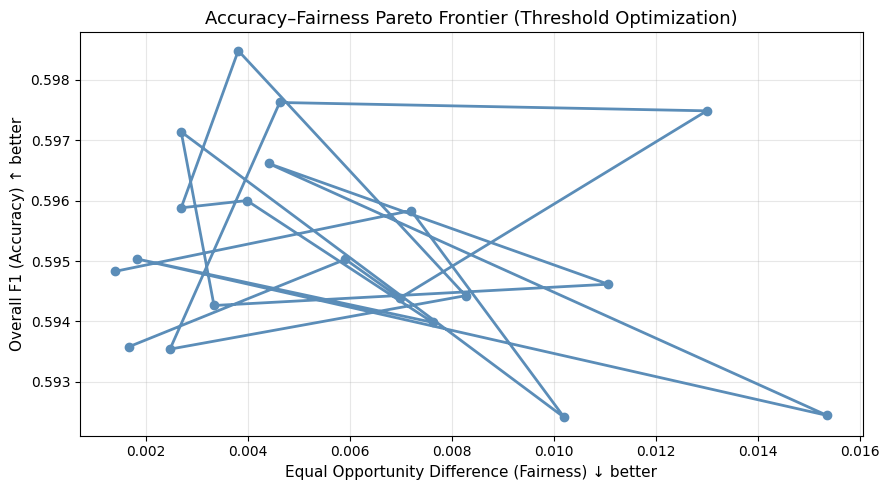

Saved part4_pareto.png


In [16]:
# Pareto frontier plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pareto_df["EqualOppDiff"], pareto_df["F1"], "o-", color="#5B8DB8", lw=2)
ax.set_xlabel("Equal Opportunity Difference (Fairness) ↓ better", fontsize=11)
ax.set_ylabel("Overall F1 (Accuracy) ↑ better", fontsize=11)
ax.set_title("Accuracy–Fairness Pareto Frontier (Threshold Optimization)", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/part4_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part4_pareto.png")

## Technique 3 — Oversampling (Data Augmentation)

In [17]:
# Duplicate all high-black training examples 3x (so each appears 4 times total)
train_black_mask = train_df["black"] >= 0.5
high_black_train = train_df[train_black_mask].copy()

train_oversampled = pd.concat(
    [train_df] + [high_black_train] * 3,
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Original training size  : {len(train_df):,}")
print(f"Oversampled training size: {len(train_oversampled):,}")
print(f"High-black rows in original   : {train_black_mask.sum():,}")
print(f"High-black rows in oversampled: {(train_oversampled['black'] >= 0.5).sum():,}")

Original training size  : 100,000
Oversampled training size: 102,433
High-black rows in original   : 811
High-black rows in oversampled: 3,244


In [18]:
OS_MODEL_DIR = "/kaggle/working/part4_os_model"
os.makedirs(OS_MODEL_DIR, exist_ok=True)

train_hf_os = Dataset.from_pandas(train_oversampled[["comment_text", "label"]])
train_hf_os = train_hf_os.map(
    lambda b: tokenizer(b["comment_text"], max_length=MAX_LENGTH,
                        truncation=True, padding="max_length"),
    batched=True, batch_size=1000, remove_columns=["comment_text"]
)
train_hf_os.set_format("torch", columns=["input_ids", "attention_mask", "label"])

os_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
os_model.to(DEVICE)

os_args = TrainingArguments(
    output_dir                  = OS_MODEL_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = 2e-5,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    logging_steps               = 200,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = "none",
)

os_trainer = Trainer(
    model           = os_model,
    args            = os_args,
    train_dataset   = train_hf_os,
    eval_dataset    = eval_hf,
    compute_metrics = compute_metrics,
)

print("Training oversampled model …")
os_trainer.train()
print("Oversampling training complete.")

Map:   0%|          | 0/102433 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training oversampled model …


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.286029,0.281384,0.812261,0.942000
2,0.218766,0.279804,0.812848,0.946100
3,0.149535,0.321420,0.812857,0.946150


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Oversampling training complete.


In [19]:
os_probs = get_probs_from_trainer(os_trainer, eval_hf)
os_preds = (os_probs >= THRESHOLD).astype(int)

metrics_os = full_metrics(
    eval_df["label"].values,              os_preds,
    eval_df.loc[eval_black_mask, "label"].values, os_preds[eval_black_mask],
    eval_df.loc[eval_ref_mask,   "label"].values, os_preds[eval_ref_mask],
    eval_df["group"].values, "Oversampling"
)
print("Oversampling metrics:", metrics_os)
np.save("/kaggle/working/os_probs.npy", os_probs)
os_trainer.save_model(OS_MODEL_DIR)

Oversampling metrics: {'Technique': 'Oversampling', 'Overall F1': 0.8129, 'High-black FPR': np.float64(0.1583), 'Reference FPR': np.float64(0.1517), 'Stat Parity Diff': np.float64(0.2554), 'Equal Opp Diff': 0.132}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Comparison Table

In [20]:
all_metrics = [baseline, metrics_rw, metrics_to, metrics_os]
comparison_df = pd.DataFrame(all_metrics)
print("\n=== Full Mitigation Comparison Table ===")
print(comparison_df.to_string(index=False))
comparison_df.to_csv("/kaggle/working/part4_comparison.csv", index=False)


=== Full Mitigation Comparison Table ===
     Technique  Overall F1  High-black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
      Baseline      0.8085          0.3083         0.2621            0.3652          0.2702
    Reweighing      0.8107          0.1667         0.1724            0.2507          0.1367
Threshold Opt.      0.5946          0.2583         0.7724            0.1163          0.0025
  Oversampling      0.8129          0.1583         0.1517            0.2554          0.1320


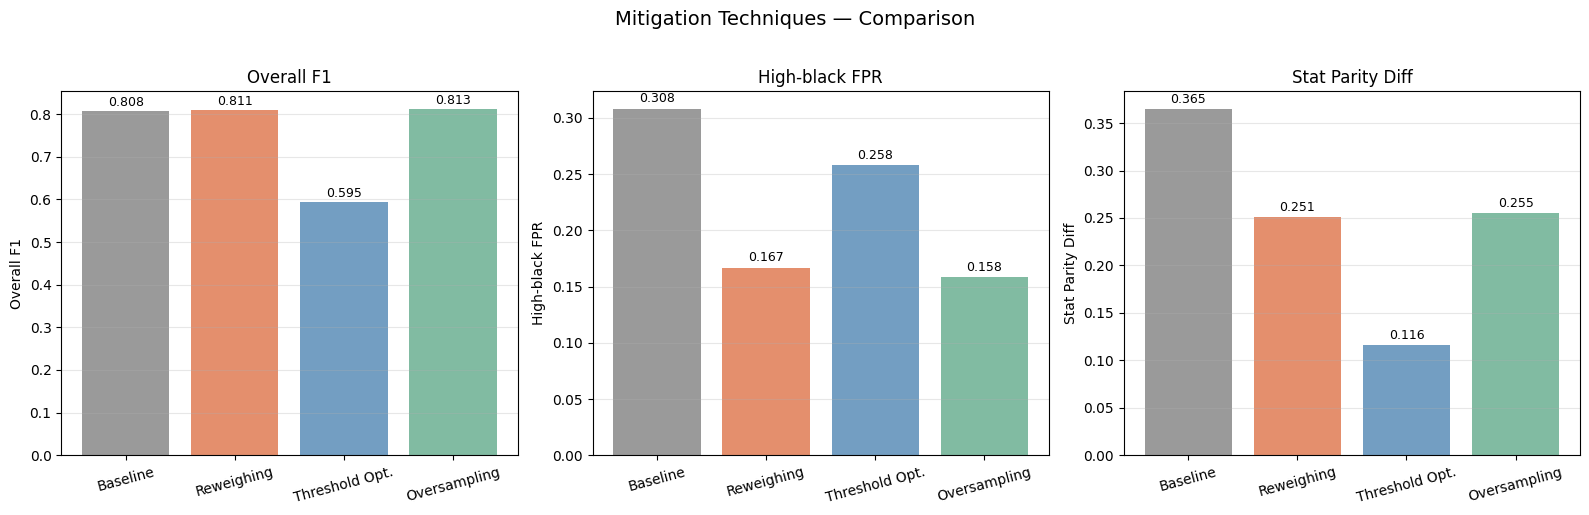

Saved part4_comparison_bar.png


In [21]:
# ── Comparison bar chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
techniques = comparison_df["Technique"].tolist()
colors     = ["#888888", "#E07B54", "#5B8DB8", "#6BAF92"]
metrics_to_plot = ["Overall F1", "High-black FPR", "Stat Parity Diff"]

for ax, metric in zip(axes, metrics_to_plot):
    vals = comparison_df[metric].astype(float).tolist()
    bars = ax.bar(techniques, vals, color=colors, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Mitigation Techniques — Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/part4_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved part4_comparison_bar.png")

In [22]:
# ── Save best-performing mitigated model for Part 5 ──
# Pick technique with best trade-off: lowest High-black FPR without tanking F1
best_row = comparison_df[comparison_df["Technique"] != "Baseline"].copy()
best_row["score"] = best_row["Overall F1"] - best_row["High-black FPR"]
best_technique = best_row.loc[best_row["score"].idxmax(), "Technique"]
print(f"\nBest mitigated technique: {best_technique}")

# Copy best model to part4_best_model
import shutil
src_map = {
    "Reweighing"     : "/kaggle/working/part4_rw_model",
    "Threshold Opt." : "/kaggle/working/part4_rw_model",  # TO is post-proc, use rw base
    "Oversampling"   : "/kaggle/working/part4_os_model",
}
best_src = src_map.get(best_technique, "/kaggle/working/part4_rw_model")
best_dst = "/kaggle/working/part4_best_model"
if os.path.exists(best_dst):
    shutil.rmtree(best_dst)
shutil.copytree(best_src, best_dst)
print(f"Best model saved to {best_dst} (used in Part 5)")

# Also save best probs
best_probs_map = {
    "Reweighing"     : rw_probs,
    "Threshold Opt." : clean_probs,
    "Oversampling"   : os_probs,
}
np.save("/kaggle/working/best_probs.npy", best_probs_map.get(best_technique, os_probs))
print("Saved best_probs.npy")


Best mitigated technique: Oversampling
Best model saved to /kaggle/working/part4_best_model (used in Part 5)
Saved best_probs.npy


## Key Question — Can You Simultaneously Achieve Demographic Parity AND Equalized Odds?
#
**Short answer: No — and this is a mathematical impossibility when base rates differ.**
#
From our cohort analysis in Part 2, the high-black and reference cohorts have
different toxic prevalence rates (base rates). When two groups have unequal
base rates, it is mathematically impossible to simultaneously satisfy:
#
- **Demographic parity** (equal positive prediction rates across groups), and
- **Equalized odds** (equal TPR AND FPR across groups)
#
unless the classifier is perfect (zero error) — which no real model achieves.
#
**Why they are incompatible:**
#
Demographic parity requires P(ŷ=1 | group=black) = P(ŷ=1 | group=white).
Equalized odds requires TPR_black = TPR_white AND FPR_black = FPR_white.
#
If base rates differ — say toxic rate is p_b in the black cohort and p_w in
the white cohort, with p_b ≠ p_w — then matching both TPR and FPR across
groups forces the positive prediction rates to differ by exactly
(p_b - p_w) × (TPR - FPR). Since a useful classifier has TPR > FPR,
and p_b ≠ p_w, the two constraints cannot both hold simultaneously.
This is a formal result known as the Chouldechova (2017) impossibility theorem.
#
**What this means practically:**
#
Any mitigation technique must choose a fairness criterion. Technique 2
(ThresholdOptimizer with equalized_odds) explicitly optimises for equalized
odds — it will reduce the TPR/FPR gap but will not achieve demographic parity,
and the Pareto plot shows the cost in overall F1 as the fairness constraint
is tightened. There is no free lunch: every point on the Pareto frontier
represents a deliberate engineering trade-off the platform must own.

In [23]:
print("Part 4 complete.")
print("Files written to /kaggle/working/:")
print("  - part4_comparison.csv")
print("  - part4_comparison_bar.png")
print("  - part4_pareto.png")
print("  - part4_rw_model/")
print("  - part4_os_model/")
print("  - part4_best_model/   ← used in Part 5")
print("  - best_probs.npy")
print("  - rw_probs.npy")
print("  - os_probs.npy")

Part 4 complete.
Files written to /kaggle/working/:
  - part4_comparison.csv
  - part4_comparison_bar.png
  - part4_pareto.png
  - part4_rw_model/
  - part4_os_model/
  - part4_best_model/   ← used in Part 5
  - best_probs.npy
  - rw_probs.npy
  - os_probs.npy


In [24]:
!zip -r working.zip /kaggle/working/part4_best_model


  adding: kaggle/working/part4_best_model/ (stored 0%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/ (stored 0%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/model.safetensors (deflated 8%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/training_args.bin (deflated 53%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/scaler.pt (deflated 64%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/rng_state.pth (deflated 26%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/config.json (deflated 49%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/scheduler.pt (deflated 61%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/trainer_state.json (deflated 68%)
  adding: kaggle/working/part4_best_model/checkpoint-3202/optimizer.pt (deflated 14%)
  adding: kaggle/working/part4_best_model/model.safetensors (deflated 8%)
  adding: kaggle/working/part4_best_model/training_args.bin (deflated 53%)
  adding: kaggle/working/

In [25]:
!pip install -q pydrive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 14.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done


In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive

gauth = GoogleAuth()
gauth.LocalWebserverAuth()  # opens auth link
drive = GoogleDrive(gauth)

file = drive.CreateFile({'title': 'working.zip'})
file.SetContentFile('/kaggle/working/working.zip')
file.Upload()

print("Uploaded!")